# Compute GLORYs EOFs V.02
## Created by Dani Lafarga 12/19/2024

Modified to normalize each PC by its standard deviation, then calculate EOF spatial pattern. 


In [1]:
import numpy as np
from numpy import meshgrid
import scipy.io as sc
import os
from pprint import pprint
import matplotlib.pyplot as plt
from numpy import linspace
from numpy import meshgrid
from mpl_toolkits.basemap import Basemap
import matplotlib as mpl
import matplotlib
import math
import time

import netCDF4 as nc 
from netCDF4 import Dataset as ds

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
top2 = cm.get_cmap('winter')
bottom2 = cm.get_cmap('hot_r')
newcolors2 = np.vstack((top2(np.linspace(0, 1, 128)),   # I want all of the winter cmap and it will only explain 100 points
                    bottom2(np.linspace(.1, .9, 128)))) # I dont want the extremes of hot cmap but it will explain 128 points
newcmp2 = ListedColormap(newcolors2, name='OrangeBlue')


import warnings
warnings.filterwarnings("ignore")



#################################################################################################################
#################################################################################################################

# Function creates a folder if it doesnt already exist
# Input:
#         - folder_path: string with the path name to folder

def create_folder(folder_path):
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder '{folder_path}' created.")
    else:
        print(f"Folder '{folder_path}' already exists.")
#################################################################################################################
#################################################################################################################
# Function get_var() will get common variables that will be required for climatologies,
# anomalies, and EOFs
# Input: 
#         - MON_INDEX: month index tells us home many years we will have 
#              Months 1-6 have 29 years
#              Months 7-12 only have 28 years
#              MON_INDEX = 0 means 3 month season
# Output: 
#         - lat: 1d array with all latitude values
#         - lon: 1d array with all longitude values
#         - depth: 1d array with all depth values
#         - years: 1d array with all year values
def get_var():
    fn     = 'thetao.mon.mean.1994.nc'
    fn     = os.path.join(data_directory, fn)
    fn     =  ds(fn,'r')
    lat    = fn.variables['latitude'][:].data    # read in latitude
    lon    = fn.variables['longitude'][:].data   # read in longitude
    depths = fn.variables['depth'][:].data       # read in depth
    fn.close()
    return lat, lon, depths
#################################################################################################################
#################################################################################################################
# Function compute volume weights based on latitude and depthe values. Although longitude values are not
# in the equation the length of the longitude array is necessary for building 3D volume weight array 
# Input:
#         - lat: 1d array with all latitude values
#         - lon: 1d array with all longitude values
#         - depth: 1d array with all depth values
# Output: 
#         - area_weight: 3D array 
def vol_weight(depths, lon, lat):
    xx, yy = meshgrid(lon, lat)
    tot_depth = len(depths)
    
    # area weight for lattitude values
    area_w = np.cos(yy*math.pi/180)
    if lat[-1] == 90.0:
        area_w[-1,:] = 0.0
    # area weights for depth
    area_weight = []
    for i in range(tot_depth):
        if i == 0:
            area_weight.append(np.sqrt(depths[0] * area_w)) # first depth thickness
        else:
            area_weight.append( np.sqrt((depths[i] - depths[i - 1]) * area_w))
    # Turning weights into one array
    area_weight = np.array(area_weight)
    return area_weight        
#################################################################################################################
#################################################################################################################
# Function converts longitude from 0 to 360 to centered at 180. This is just for naming purposes.
# it does not shift the axis of the data
# Input:
#         - lon_0_360: float with the longitude value from 0 to 360
# Output:
#         - convert: String with the longitude value on a 180 centered scale

# Important Variables:
#         - lon_180_w_180_e: float with the longitude value on a 180 centered scale
def convert_longitude(lon_0_360):
    lon_180_w_180_e = lon_0_360 - 360 if lon_0_360 > 180 else lon_0_360
    if lon_180_w_180_e < 0:
        lon_180_w_180_e = abs(lon_180_w_180_e)
        convert = f"{lon_180_w_180_e}$^\xb0$W"
    else:
        convert = f"{lon_180_w_180_e}$^\xb0$E"
    return convert

C:\Users\bubby\AppData\Local\Temp\ipykernel_12216\3426158065.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  top2 = cm.get_cmap('winter')
C:\Users\bubby\AppData\Local\Temp\ipykernel_12216\3426158065.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bottom2 = cm.get_cmap('hot_r')


# Section 1: Defining ALL directories and Base array variables
Base array variabels:
- lat: latitude from uncut data
- lon: longitude from uncut data
- depths: depth from uncut data
- years: defined years, this is set by user
- cut_lat: cut lattitude values based on lat_start and lat_end
- cut_lon: cut longitude values based on lon_start and lon_end
- cut_depths: cut depth values based on depth_end

In [2]:
#################################################################################################################
#################################################################################################################
# Function will set main data directory
# Input:
# Output: None as the function will only be setting the directories to read from 
# Important Variables:
#         - data_directory: directory with the raw GLORYs data
def set_directory():
    global data_directory
    path = 'F:/GLORYS/'
    if not os.path.exists(path):
        data_directory = '/Volumes/Elements/GLORYS'
    else:
        data_directory = path
    return
set_directory()
month = 'Winter'
lat, lon, depths = get_var()


####### SELECT REGION ########
'''
region = "Pacific"


# for the entire Pacific
lat_start = 720
lat_end   = 1801
lon_start = 1440
lon_end   = 3600

# Not sure which one to do
#depth_end = len(depths)
depth_end = 32
'''

region = "Global"

# Global
lat_start = 0
lat_end   = len(lat)
lon_start = 0
lon_end   = len(lon)
depth_end = len(depths)


############################


anomalies_directory     = os.path.join(data_directory, 'Anomalies/Winter Avg')
EOF_directory           = os.path.join(data_directory, 'cut_EOFs/Winter Avg/' + region +'/')
create_folder(EOF_directory) # if directory doesnt exist create it


Folder 'F:/GLORYS/cut_EOFs/Winter Avg/Global/' already exists.


In [3]:


# for the NP
'''
lat_start = 1200
lat_end   = 1741
lon_start = 1260
lon_end   = 3121
'''

'''
# for the entire Pacific
lat_start = 720
lat_end   = 1801
lon_start = 1440
lon_end   = 3600

# Not sure which one to do
#depth_end = len(depths)
depth_end = 32
'''
'''
# for ENSO
lat_start = 600
lat_end   = 1321
lon_start = 1320
lon_end   = 3481

'''
'''
# Global
lat_start = 0
lat_end   = len(lat)
lon_start = 0
lon_end   = len(lon)
depth_end = len(depths)
'''


# depth_end = 32 # first 500 m
# lat_start = 720
# lat_end   = 1801
# lon_start = 1440
# lon_end   = 3600

years  = np.linspace(1994, 2021,28, dtype="int")

cut_lat = lat[lat_start:lat_end]
cut_lon = lon[lon_start:lon_end]
cut_depths = depths[:depth_end]


#print(len(depths))


#print(years)

# Section 2: Compute Covariance

In [4]:
#################################################################################################################
#################################################################################################################
# Function reads in cut anomalies, will tak eout NaNs, and then flattten to a 1D array
# 
# Input:
#         - year: int with the year to read in
# Output:
#         - anom: 1d array that contains anomalies of the file without any NaN
def read_anom_compressed(year):
    fn   = month + '.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)       # join with the directory that can be changed
    nc0  = ds(fn, 'r')
    anom = nc0.variables['anom'][:depth_end, lat_start:lat_end, lon_start:lon_end]
    if anom.shape[2] == len(lon):                  # for full ocean there is a mismatch
        anom.mask[13, 969, 3717] = True
    anom = anom.compressed()                           # flatttentens and gets rid of NaN
    nc0.close()
    return anom
#################################################################################################################
#################################################################################################################
# Function computes the covariance matrix in time for the data. 
# Covariance is computed by doing the dot product of one anomally array at time t
# with all other anomalies at time t'. 
# to avoid redundancies the code will explot the symmetry of the covariance matrix
'''
Example
   Anomaly Mult: 
            let t = 2
                   o t' = t+1
                                        anom(t) * anom(t+1) = a
                                        -> cov(2,3) = cov(3,2) = a
                   o t' = t+2
                                        anom(t) * anom(t+2) = b
                                        -> cov(2,4) = cov(4,2) = b
                   o t' = t+3
                                        anom(t) * anom(t+3) = c
                                        -> cov(2,5) = cov(5,2) = c
                                                ┌               ┐
                                        cov =   │  # # # # # #  │
                                                │  # # # # # #  │
                                                │  # # t a b c  │
                                                │  # # a # # #  │
                                                │  # # b # # #  │
                                                │  # # c # # #  │
                                                └               ┘
'''
# Input:
#         - years: 1D array of ints with all years to be used in computation. These are all 
#                  the anomalies which will be read in 
# Output:
#         - covariance_mat: 2D covariance matrix(floats)
# Important Variables:   
#         - Y: total amount of years. This will give us the dimensions for our square covariance matrix (Y by Y)
#         - t: the time index(int). this will tell us what diagonal we are on so we can exploit symmetry.
#         - anom: anomalies at time t. 
#         - t_prime: all values from t+1 to the last time step index(int)
#         - year_prime: the year value of t_prime
#             example: years = [1993, 2021], if t = 0 so year = 1993, t' = 1:29, and year' = 1994:2021
#         - anom_tprime: anomalies at time t'
def cov_mat(years):
    Y = len(years)
    covariance_mat = np.zeros((Y,Y))
    for t,year in enumerate(years):
        anom = read_anom_compressed(year)
        for t_prime,year_prime in enumerate(years[t:]):
            anom_tprime = read_anom_compressed(year_prime)
            covariance_mat[t,t + t_prime] = np.dot(anom, anom_tprime)
            covariance_mat[t + t_prime,t] = covariance_mat[t,t + t_prime]
    return covariance_mat

In [5]:
#Uncomment to create covariance matrix


start = time.time()
cov = cov_mat(years)
end = time.time()
print(end-start)

7128.377424240112


In [6]:
def sav_cov_mat(cov_mat):
    wn = month+'_covariance_matrix.csv'
    fn     = os.path.join(EOF_directory, wn)
    np.savetxt(fn, cov_mat, delimiter=",")
    print(fn)


def read_cov_mat():
    wn = month+'_covariance_matrix.csv'
    fn     = os.path.join(EOF_directory, wn)
    np.genfromtxt(fn, delimiter=',')

In [17]:
sav_cov_mat(cov)

F:/GLORYS/cut_EOFs/Winter Avg/Global/Winter_covariance_matrix.csv


In [8]:
cov = read_cov_mat()

# Section 3: Compute eigenvalues/eigenvectors

In [5]:
import csv

In [6]:
#################################################################################################################
#################################################################################################################
# Function computes eigenvectors and values of the covariance matrix and sort them by variance greatest to least
# function will also check to make sure they are normalized and orthogonal
# Input:
#         - cov: 2D covariance matrix. Cannot have any NaNs!
# Output:
#         - eigvals: 1D array with all eigenvalues of covariance matrix sorted (float)
#         - eigvecs: 2D matrix with corresponding sorted eigenvectors of covariance matrix (float)
# Important Variables: 
def find_eigen(cov):
    eigvals, eigvecs = np.linalg.eig(cov)
    eigvecs = np.array(eigvecs)
    
    # Check to make sure vectors are orthogonal
    n, m = eigvecs.shape
    for col_i in range(m):
        for col_j in range(m):
            if col_i < col_j:  # use strictly less than because we don't want to consider a column with itself, and the dot product is commutable so order doesn't matter
                is_orthogonal = np.dot(eigvecs[:, col_i], eigvecs[:, col_j])
                if not np.isclose(is_orthogonal, 0):
                    raise ValueError(f"Eigenvector {col_i} and Eigenvector {col_j} are not orthogonal.")
    # checking magnitude of evals
    for col_i in range(m):
        is_one = np.linalg.norm(eigvecs[:,col_i])
        if not np.isclose(is_one, 1):
            raise ValueError(f"Eigenvector {col_i} is not one")
            
    # sort eigenvalues and eigenvectors
    eig_index = np.argsort(eigvals)
    eig_index = np.flip(eig_index)
    
    new_eigvals = eigvals[eig_index[:]]
    eigvals = new_eigvals

    # Normalize eigenvectors (PC's) by their standard deviation 
    new_eigvecs = eigvecs[:,eig_index]
    #eigvec_sd = np.std(new_eigvecs, axis = 0)
    eigvecs = new_eigvecs #* eigvec_sd
    return eigvals,eigvecs


#################################################################################################################
#################################################################################################################
# Function computes eigenvectors and values of the covariance matrix and sort them by variance greatest to least
# function will also check to make sure they are normalized and orthogonal
# Input:
#         - cov: 2D covariance matrix. Cannot have any NaNs!
# Output:
#         - eigvals: 1D array with all eigenvalues of covariance matrix sorted (float)
#         - eigvecs: 2D matrix with corresponding sorted eigenvectors of covariance matrix (float)
# Important Variables: 
def find_eigen_normalized(cov):
    eigvals, eigvecs = np.linalg.eig(cov)
    eigvecs = np.array(eigvecs)
    
    # Check to make sure vectors are orthogonal
    n, m = eigvecs.shape
    for col_i in range(m):
        for col_j in range(m):
            if col_i < col_j:  # use strictly less than because we don't want to consider a column with itself, and the dot product is commutable so order doesn't matter
                is_orthogonal = np.dot(eigvecs[:, col_i], eigvecs[:, col_j])
                if not np.isclose(is_orthogonal, 0):
                    raise ValueError(f"Eigenvector {col_i} and Eigenvector {col_j} are not orthogonal.")
    # checking magnitude of evals
    for col_i in range(m):
        is_one = np.linalg.norm(eigvecs[:,col_i])
        if not np.isclose(is_one, 1):
            raise ValueError(f"Eigenvector {col_i} is not one")
            
    # sort eigenvalues and eigenvectors
    eig_index = np.argsort(eigvals)
    eig_index = np.flip(eig_index)
    
    new_eigvals = eigvals[eig_index[:]]
    eigvals = new_eigvals

    # Normalize eigenvectors (PC's) by their standard deviation 
    new_eigvecs = eigvecs[:,eig_index]
    eigvec_sd = np.std(new_eigvecs, axis = 0)
    eigvecs = new_eigvecs * eigvec_sd
    return eigvals,eigvecs


#################################################################################################################
#################################################################################################################
# Function saves eigenvalues and eigencvectors into a csv file 
# 
# Input:
#         - eigvals: 1D array with eigenvalues
#         - eigvecs: 2D matrix with eigenvectors
#         - month: string with the month the eigenvec/eigenvals belong to
# Output:
#         - None: function saves to a file 
def save_evals(eigvals,eigvecs,month, normalizationFlag):
    # Prepare data for saving
    # Create a 2D array with eigenvalues and eigenvectors
    data = np.hstack((eigvals.reshape(-1, 1), eigvecs.T))
    
    # Save to CSV file
    create_folder(EOF_directory)
    fn     = month+'_eigenvalues_eigenvectors' + normalizationFlag + '.csv'
    fn     = os.path.join(EOF_directory, fn)
    with open(fn, 'w', newline='') as file:
        writer = csv.writer(file)
        
        # Write the header
        header = ['Eigenvalue'] + [f'Eigenvector {i+1}' for i in range(eigvecs.shape[1])]
        writer.writerow(header)
        
        # Write the data
        for row in data:
            writer.writerow(row)
    
    print("Eigenvalues and eigenvectors saved to" + fn)

In [9]:
eigvals,eigvecs = find_eigen(cov)
save_evals(eigvals,eigvecs,'Winter Avg', '')
eigvals,eigvecsNormal = find_eigen_normalized(cov)

save_evals(eigvals,eigvecsNormal,'Winter Avg', '_normalized')

Folder 'F:/GLORYS/cut_EOFs/Winter Avg/Global/' already exists.
Eigenvalues and eigenvectors saved to 'eigenvalues_eigenvectors.csv'
Folder 'F:/GLORYS/cut_EOFs/Winter Avg/Global/' already exists.
Eigenvalues and eigenvectors saved to 'eigenvalues_eigenvectors.csv'


In [10]:
'''
import matplotlib.pyplot as plt
#import plot_all
title_sz = 19
label_sz = title_sz
tick_sz = 5
line = 3

fig = plt.figure(figsize=(11., 7.))

ax = fig.add_subplot(2,1,1)
mode = 1
plot_all.pc_plot_multi_fig(mode, eigvecs, years)
plt.title('Winter PC ' + str(mode) , fontsize = title_sz)
plt.ylabel('(a)', rotation = 'horizontal', size = label_sz)
plt.grid(True)
ax.set_xticklabels([])  # Remove x tick labels

ax = fig.add_subplot(2,1,2)
mode = 2
plot_all.pc_plot_multi_fig(mode, eigvecs, years)
plt.title('Winter PC ' + str(mode) , fontsize = title_sz)
plt.ylabel('(b)', rotation = 'horizontal', size = label_sz)
plt.xlabel('Year', fontsize = label_sz)
plt.grid(True)
plt.axhline(y=0, color='k', linewidth=1)  # Make the 0 line thicker


#plt.savefig('E:/Paper Figs/3D NP Winter PC.png', dpi=300, bbox_inches='tight')
plt.show()

'''

"\nimport matplotlib.pyplot as plt\n#import plot_all\ntitle_sz = 19\nlabel_sz = title_sz\ntick_sz = 5\nline = 3\n\nfig = plt.figure(figsize=(11., 7.))\n\nax = fig.add_subplot(2,1,1)\nmode = 1\nplot_all.pc_plot_multi_fig(mode, eigvecs, years)\nplt.title('Winter PC ' + str(mode) , fontsize = title_sz)\nplt.ylabel('(a)', rotation = 'horizontal', size = label_sz)\nplt.grid(True)\nax.set_xticklabels([])  # Remove x tick labels\n\nax = fig.add_subplot(2,1,2)\nmode = 2\nplot_all.pc_plot_multi_fig(mode, eigvecs, years)\nplt.title('Winter PC ' + str(mode) , fontsize = title_sz)\nplt.ylabel('(b)', rotation = 'horizontal', size = label_sz)\nplt.xlabel('Year', fontsize = label_sz)\nplt.grid(True)\nplt.axhline(y=0, color='k', linewidth=1)  # Make the 0 line thicker\n\n\n#plt.savefig('E:/Paper Figs/3D NP Winter PC.png', dpi=300, bbox_inches='tight')\nplt.show()\n\n"

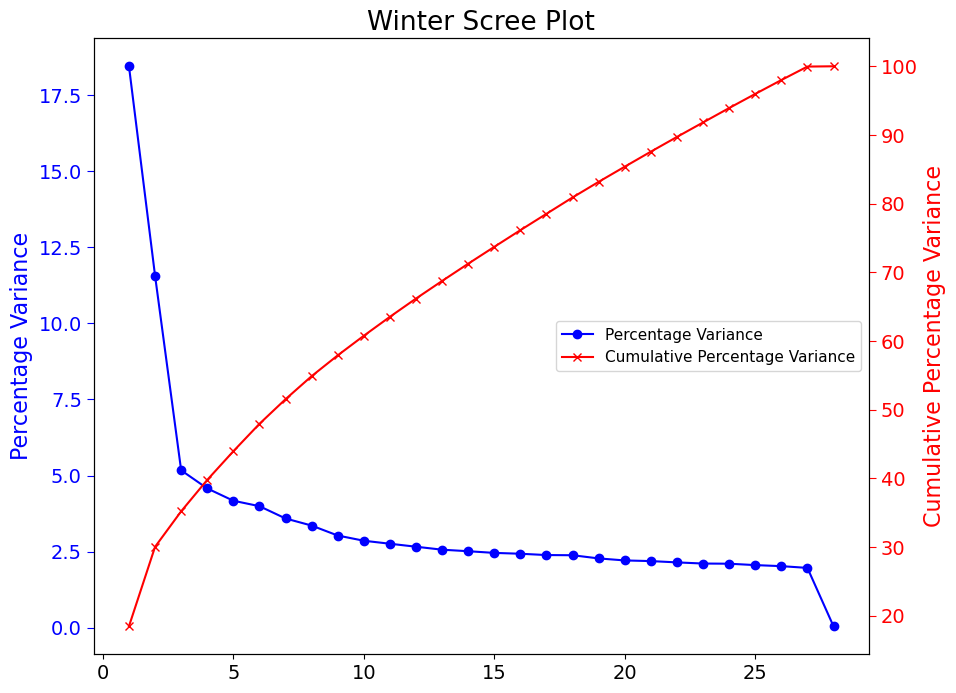

In [11]:
num_eval = np.arange(eigvals.shape[0])+1 # mode numbers
cumulative_eval = np.cumsum(eigvals) # compute cummulative variance
fig, ax = plt.subplots()

fig.set_size_inches(10., 8.)
title_sz = 19
label_sz = title_sz-3
tick_sz = 5
# plotting Percentage Variance
p1, = plt.plot(num_eval,(eigvals/cumulative_eval[-1])*100, 'b',marker = 'o',label = 'Percentage Variance')
# formatting for left axis
ax.set_ylabel("Percentage Variance", size = label_sz)
ax.tick_params('y', colors='b',size = tick_sz, labelsize = label_sz-2)
ax.yaxis.label.set_color('blue')
plt.xticks(fontsize= label_sz-2)

# plotting Cummulative Percentage Variance
ax2 = ax.twinx()
p2, = plt.plot(num_eval,(cumulative_eval/cumulative_eval[-1])*100,'r',marker = 'x',label = 'Cumulative Percentage Variance')

# formatting for right axis
ax2.tick_params('y', colors='r',size = tick_sz, labelsize = label_sz-2)
ax2.set_ylabel("Cumulative Percentage Variance", size = label_sz)
ax2.yaxis.label.set_color('red')


plt.legend(handles=[p1,p2],loc='center right', fontsize = label_sz-5)
plt.title('Winter Scree Plot', size = title_sz)

plt.show()

# Section 4: Compute EOFs in parts

### Space time anomaly Matrix:
$$
A[i,t] =
\begin{equation}
    \begin{pmatrix}
      \vec{a}_{l_1,Y_{1993}} & \vec{a}_{l_1,Y_{1994}} & ... & \vec{a}_{l_1,Y_{2021}} \\
      \vec{a}_{l_2,Y_{1993}} & \vec{a}_{l_2,Y_{1994}} & ... & \vec{a}_{l_2,Y_{2021}} \\
      \vec{a}_{l_3,Y_{1993}} & \vec{a}_{l_3,Y_{1994}} & ... & \vec{a}_{l_3,Y_{2021}} \\
      ...            & ...            & ...            & ...   & ...            & ...\\
      \vec{a}_{l_{32},Y_{1993}} & \vec{a}_{l_{32},Y_{1994}} & ... & \vec{a}_{l_{32},Y_{2021}} \\
    \end{pmatrix}
\end{equation}
$$
Where each vector $\vec{a}$ is an anomaly at a depth level $l$ and a timestep $Y$. Let an eigenvector be defined as $\vec{v_k}$ where $k$ is the eigenvector number or mode number. There are a total of Y modes that are used. Defining an eigenvector matrix:
\begin{equation}
V = 
\begin{pmatrix}
\vec{v}_1 & \vec{v}_2 & ... & \vec{v}_Y
\end{pmatrix}
\end{equation}
We can then define our EOFs as a result of dot product of the anomalies and eigenvectors divided by its magnitude:
\begin{equation}
EOF = \frac{AV}{||AV||}
\end{equation}

This algorithm breaks up this computation so that it reads anomalies a chunk at a time and writes to EOF files a chunk at a time. 

Algorithm will skip over any row that is NaN which is consistent for every year.

In [7]:
#################################################################################################################
#################################################################################################################
# Function checks if a file exists and if it does, continues to the next iteration.
# Input:
#         - file_path: string with the path name to folder
# Outputs:
#         - True if file doesnt exists
#         - False if file exists
# Important Variables: 
def check_file_and_continue(file_path):
    if os.path.exists(file_path):
        print(f"File '{file_path}' exists. Moving to next iteration.")
        return False
    else:
        return True
#################################################################################################################
#################################################################################################################
# Function reads in raw cut anomalies
# 
# Input:
#         - year: int with the specific year to read
# Output:
#         - anom: 3D array of dim (depth, lat, lon) with the anomaly data
def read_anom_raw(year):
    fn   = month +'.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)  # join with the directory that can be changed
    nc0 = ds(fn, 'r')
    anom = nc0.variables['anom'][:depth_end, lat_start:lat_end, lon_start:lon_end]
    if anom.shape[2] == len(lon):              # for full ocean there is a mismatch
        anom.mask[13, 969, 3717] = True
    anom = anom.filled()
    nc0.close()
    return anom
#################################################################################################################
#################################################################################################################
# Function reads anomaly data but only outputs matrix with no NaNs
# depth is specified to save RAM while reading. Without the specified depth you would be reading in all depths
# Input:
#         - year: int with the specific year to read
#         - depth: int with specified depth index not actual depth value. This is used to save space when reading in so we aren't reading in all depths 
#         - read: 2D array with indexes of what row and column has data. 
#                 read[:,0]- the rows with data
#                 read[:,1]- the columns with data
# Output:
#         - anom: 2D matrix at specified year and depth with no NaNs

def read_anom_parts(year,depth,read):
    fn   = month +'.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)      # join with the directory that can be changed
    nc0 = ds(fn, 'r')
    anom = nc0.variables['anom'][depth, lat_start:lat_end, lon_start:lon_end]
    if anom.shape[1] == len(lon) and depth == 13:  # for full ocean there is a mismatch
        anom.mask[969, 3717] = True
    anom = anom.filled()
    nc0.close()
    anom = anom[read[:,0], read[:,1]]
    return anom
#################################################################################################################
#################################################################################################################
# Function Created the files which will be aggregated a chunk at a time.
# The files must be created  first so we can more easily access and aggregate them.
# Input:
#         - month: string  where to save the EOFs
#         - total_modes: int with the total amount of modes I want. 
#                        Maximum is the total amount of time steps
# Output:
#         - None: the function will create files for all EOF modes
# Important Variables: 
def create_EOF_files(total_modes):
    create_folder(EOF_directory)                  # create folder named by the month
    anom_base = read_anom_raw(1998)                  # read in one anomaly to base the dimensions of EOF
    EOF_mat = np.full_like(anom_base, np.nan)     # create a matrix with the same dim size as the anomalies
    for mode in range(1,total_modes+1):           # for all the modes
        # Create a new NetCDF file
        fn = 'EOF_'+str(mode)+'.nc'               # file name for EOFs
        fn     = os.path.join(EOF_directory, fn)  # join with EOF path
        if not check_file_and_continue(fn):                      # if the file does already exist continue
            continue;
        ncfile = ds(fn, 'w', format='NETCDF4')                   # if the file doesnt exist create it
        
        # Define dimensions
        ncfile.createDimension('depth', EOF_mat.shape[0])
        ncfile.createDimension('lat', EOF_mat.shape[1])
        ncfile.createDimension('lon', EOF_mat.shape[2])
        
        # Create a variable for EOFs
        var = ncfile.createVariable('EOF', 'f4', ('depth', 'lat', 'lon'), fill_value = np.nan)
        var[:] = EOF_mat # save the empty EOF
        ncfile.close()   # close the file
    print(f"Total of '{mode}' EOF files created")
#################################################################################################################
#################################################################################################################
# Function computes EOFs in parts. 
# To save on RAM we exclude points with NaN when reading
# Input:
#         - years: 1D int array with all years to read in of the anomalies.
#                  Length of this will also be the max amount of modes
# Output:
#         - None: function saves all EOF modes in sperate files
# Important Variables: 
#         - total_modes: int of the total amount of modes to compute. The default is the max (see input for max)
#         - num_ind: 2D array that tells us which indexes have ocean data(excludes land/NaN).
#         - chunk_size: the total amount of grid points to read in each year. Remember we are excluding NaN so
#                       this is total grid points with data that we are reading in
#         - read: a subset of num_ind that contains a total of chunk_size indexes for that iteration. 
#                 This variable makes sure we are not reading the same chunk, and the for loop it is in makes
#                 sure we read to the end even if the last chunk is less than chunk_size
#         - anom_mat: 2D space time anomaly matrix without NaN. This is at most dim(chunk_size, Y)
#         - EOF_mat: 3D Array of size (depth, lat, lon). This contains the resulting EOFs from the 
#                    multiplication.  
#                   NOTE: this matrix does contain NaNs. We make sure that the resulting multiplacation goes
#                         to the correct index bny uising the variable read for the indexing. 
def compute_EOFs(years):
    start = time.time()                                      # for timing 
    total_modes = len(years)+1                               # total amount of modes to compute
    anom_base = read_anom_raw(1994)                          # read in one anomaly file for dimensions
    for i in range(anom_base.shape[0]):                      # for each depth
        num_ind = np.argwhere(~np.isnan(anom_base[i,:,:]))   # for this depth, indexes with data
        chunk_size = 8000000                                 # read in this many ocean points a year
        
        #print(len(num_ind))
        print("Depth layer: ", i)

        
        for j in range(0,len(num_ind),chunk_size):           # read in a chunk at a time until done with depth
            read = num_ind[j:j+chunk_size]                   # read chunksize of ocean data(exclude land in reading)
            anom_mat = np.zeros((len(read),len(years)))              # initialize space time data matrix
            for k,y in enumerate(years):                                  # for every year
                anom_mat[:,k] = read_anom_parts(y,i,read)    # read in ocean anomalies and put in matrix
            for mode in range(1,total_modes):                # for every mode
                # Open the EOF NetCDF file to write
                fn = 'EOF_'+str(mode)+'.nc'
                fn     = os.path.join(EOF_directory, fn)     # join with EOF path
                EOF_ncfile = ds(fn, 'a')                     # open to write (hence 'a')
                # Destination variable
                EOF = EOF_ncfile.variables['EOF']            # pointer to variable
                EOF_mat = EOF[:].filled()                    # get masked matrix and unmask it
                # compute EOFs and write to specified lat lon
                EOF_mat[i,read[:,0], read[:,1]] = anom_mat @ eigvecsNormal[:,mode-1] # multiply to get EOFs
                EOF[:] = EOF_mat                             # write to file
                EOF_ncfile.close()
    
    #normalize_EOFs(len(years)) # normalize EOFs
    end = time.time()
    print("Chunk Size: ", chunk_size)
    print("Time: ", end - start)
    
        
#################################################################################################################
#################################################################################################################    
# Function normalizes the EOFs by dividing by magnitude
# 
# Input:
#         - tot_modes: an int describing total amount of modes
# Output:
#         - None: saves the EOFs to the EOF files
# Important Variables:  
def normalize_EOFs(tot_modes):
    for mode in range(1,tot_modes+1):
        fn      = 'EOF_'+str(mode)+'.nc'
        fn      = os.path.join(EOF_directory, fn)     # join with EOF path
        EOF_ncfile = ds(fn, 'a')
        EOF     = EOF_ncfile.variables['EOF']
        EOF_mag = EOF[:].compressed()                      # flattens and gets rid of NaN
        EOF[:]  = EOF[:].filled()/np.linalg.norm(EOF_mag)  # divide by magnitude
        EOF_ncfile.close()


#################################################################################################################
#################################################################################################################    
# Function delete EOF files in directory
# 
# Input:
#         - tot_modes: an int describing total amount of modes
# Output:
#         - None: deletes the EOF files
# Important Variables:  
def delete_EOFs(tot_modes):
    for mode in range(1,tot_modes+1):
        fn      = 'EOF_'+str(mode)+'.nc'
        fn      = os.path.join(EOF_directory, fn)     # join with EOF path
        os.remove(fn)

In [11]:
#delete_EOFs(len(years))


In [13]:
create_EOF_files(len(years))

Folder 'F:/GLORYS/cut_EOFs/Winter Avg/Global/' already exists.
File 'F:/GLORYS/cut_EOFs/Winter Avg/Global/EOF_1.nc' exists. Moving to next iteration.
File 'F:/GLORYS/cut_EOFs/Winter Avg/Global/EOF_2.nc' exists. Moving to next iteration.
Total of '28' EOF files created


In [14]:
compute_EOFs(years)

Depth layer:  0
Depth layer:  1
Depth layer:  2
Depth layer:  3
Depth layer:  4
Depth layer:  5
Depth layer:  6
Depth layer:  7
Depth layer:  8
Depth layer:  9
Depth layer:  10
Depth layer:  11
Depth layer:  12
Depth layer:  13
Depth layer:  14
Depth layer:  15
Depth layer:  16
Depth layer:  17
Depth layer:  18
Depth layer:  19
Depth layer:  20
Depth layer:  21
Depth layer:  22
Depth layer:  23
Depth layer:  24
Depth layer:  25
Depth layer:  26
Depth layer:  27
Depth layer:  28
Depth layer:  29
Depth layer:  30
Depth layer:  31
Depth layer:  32
Depth layer:  33
Depth layer:  34
Depth layer:  35
Depth layer:  36
Depth layer:  37
Depth layer:  38
Depth layer:  39
Depth layer:  40
Depth layer:  41
Depth layer:  42
Depth layer:  43
Depth layer:  44
Depth layer:  45
Depth layer:  46
Depth layer:  47
Depth layer:  48
Depth layer:  49
Chunk Size:  8000000
Time:  84246.88933587074


## Processing Time Plot

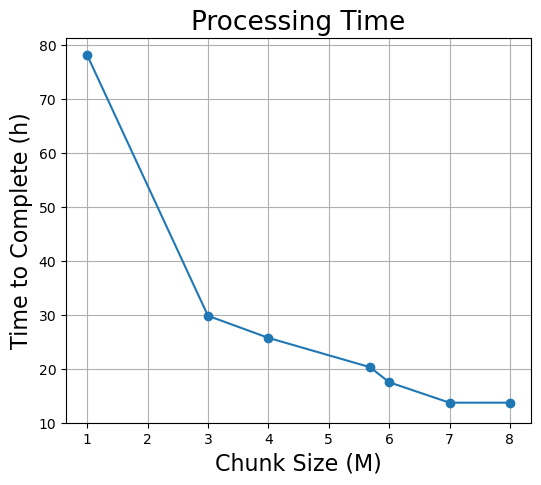

In [5]:
# Array of runtime + chunksizes
import numpy as np
from matplotlib import pyplot as plt


0.

































































































































































































































































































































































































































fig, ax = plt.subplots()

fig.set_size_inches(6., 5.)
title_sz = 19
label_sz = title_sz-3
tick_sz = 5

# Format chunk size to millions, and run time to hours
p1 = plt.plot(chunkSize/1000000, runTime/3600, marker = "o")
plt.xlabel("Chunk Size (M)", size = label_sz)
plt.ylabel("Time to Complete (h)", size = label_sz)
plt.title("Processing Time", size = title_sz)

ax.set_yticks(range(10,82, 10))

plt.grid()
plt.savefig("D:/SCIL/Paper Figs/processingTime.png")


plt.show()




## Multiprocessing EOF Calculation Code

In [ ]:
from multiprocessing import Pool 



#################################################################################################################
#################################################################################################################
# Function computes EOFs 
# To be used within next function
# Input:
#         - modes: 1D int array with amount of modes
# Output:
#         - None: function saves all EOF modes in sperate files
# Important Variables: 
#         - read: a subset of num_ind that contains a total of chunk_size indexes for that iteration. 
#                 This variable makes sure we are not reading the same chunk, and the for loop it is in makes
#                 sure we read to the end even if the last chunk is less than chunk_size
#         - anom_mat: 2D space time anomaly matrix without NaN. This is at most dim(chunk_size, Y)
#         - EOF_mat: 3D Array of size (depth, lat, lon). This contains the resulting EOFs from the 
#                    multiplication.  
#                   NOTE: this matrix does contain NaNs. We make sure that the resulting multiplacation goes
#                         to the correct index bny uising the variable read for the indexing. 

def EOF_calculation(modes): 
    
    # Open the EOF NetCDF file to write
    fn = 'EOF_'+str(mode)+'.nc'
    fn     = os.path.join(EOF_directory, fn)     # join with EOF path
    EOF_ncfile = ds(fn, 'a')                     # open to write (hence 'a')
    
    # Destination variable
    EOF = EOF_ncfile.variables['EOF']            # pointer to variable
    EOF_mat = EOF[:].filled()                    # get masked matrix and unmask it
    
    # compute EOFs and write to specified lat lon
    EOF_mat[i,read[:,0], read[:,1]] = anom_mat @ eigvecs[:,mode-1] # multiply to get EOFs
    EOF[:] = EOF_mat                             # write to file
    EOF_ncfile.close()







#################################################################################################################
#################################################################################################################
# Function computes EOFs in parts. 
# To save on RAM we exclude points with NaN when reading


#################################################################################################################
##########    TO DO ##########################################################
######################################################################

# I'm pretty sure this can be sped up using multiprocessing, Pool() methods
# However I think there would be problems with the way it currently runs
# I'm thinking the solution is to change the function so that each EOF file
# is fully processed before going onto the next file

# I think that this could be achieved by putting the EOF for loop outside the 
# the depth layer, so that instead of going depth by depth for all EOF's
# which in a multiprocessing command would have filelock issues
# it would go EOF by EOF for all depths

# I would guess this would be slower than how it's currently written
# But I'd also guess it would be substantially faster given 100% CPU usage



## ORRRRRRRRR
# We Pool right before the EOF calculation
# Since it seems like the multiprocessing works best on a 
# File open, perform thing, file close
# Putting it within the function should solve this problem


# ######################################################################



# Input:
#         - years: 1D int array with all years to read in of the anomalies.
#                  Length of this will also be the max amount of modes
# Output:
#         - None: function saves all EOF modes in sperate files
# Important Variables: 
#         - total_modes: int of the total amount of modes to compute. The default is the max (see input for max)
#         - num_ind: 2D array that tells us which indexes have ocean data(excludes land/NaN).
#         - chunk_size: the total amount of grid points to read in each year. Remember we are excluding NaN so
#                       this is total grid points with data that we are reading in
#         - read: a subset of num_ind that contains a total of chunk_size indexes for that iteration. 
#                 This variable makes sure we are not reading the same chunk, and the for loop it is in makes
#                 sure we read to the end even if the last chunk is less than chunk_size
#         - anom_mat: 2D space time anomaly matrix without NaN. This is at most dim(chunk_size, Y)
#         - EOF_mat: 3D Array of size (depth, lat, lon). This contains the resulting EOFs from the 
#                    multiplication.  
#                   NOTE: this matrix does contain NaNs. We make sure that the resulting multiplacation goes
#                         to the correct index bny uising the variable read for the indexing. 
def compute_EOFs_parallel(years):
    start = time.time()                                      # for timing 
    total_modes = len(years)+1                               # total amount of modes to compute
    anom_base = read_anom_raw(1994)                          # read in one anomaly file for dimensions
    
    # Loop through all depths
    for i in range(anom_base.shape[0]):                      
        num_ind = np.argwhere(~np.isnan(anom_base[i,:,:]))   # num_ind = array, with indexes of nonNan data at depth i
        chunk_size = 7000000                                 # read in this many ocean points a year
        
        #print(len(num_ind))                                 # check array length
        print("Depth layer: ", i)                            # print depth level to check progress

        
        for j in range(0,len(num_ind),chunk_size):           # read in a chunk at a time until done with depth
            read = num_ind[j:j+chunk_size]                   # read chunksize of ocean data(exclude land in reading)
            anom_mat = np.zeros((len(read),len(years)))              # initialize space time data matrix
            for k,y in enumerate(years):                                  # for every year
                anom_mat[:,k] = read_anom_parts(y,i,read)    # read in ocean anomalies and put in matrix
            
            modes = range(1,total_modes)                   # Array of every mode
            
            with Pool(processes = 4) as pool:
                pool.map(EOF_calculation, modes)
    
    normalize_EOFs(len(years)) # normalize EOFs
    end = time.time()
    print("Chunk Size: ", chunk_size)
    print("Time: ", end - start)

In [48]:
# Delete previous EOF Files
delete_EOFs(len(years))
# Create new ones
create_EOF_files(len(years))

Folder 'F:/GLORYS/cut_EOFs/Winter Avg' already exists.
Total of '28' EOF files created


In [ ]:
compute_EOFs_parallel(years)

Depth layer:  0


## Section 4.1: visualization

In [17]:
mode = 1
fn   = 'EOF_'+str(mode)+'.nc'
fn   = os.path.join(EOF_directory, fn)       # join with EOF path
EOF_ncfile = ds(fn, 'r')
EOF = EOF_ncfile.variables['EOF']
EOF = EOF[:].filled()
EOF_ncfile.close()

area_weight = vol_weight(cut_depths, cut_lon, cut_lat)
EOF = EOF/area_weight  # remember to div by area weight 

print(fn)

F:/GLORYS/cut_EOFs/Winter Avg/Global/EOF_1.nc


In [18]:
title_sz = 19
label_sz = title_sz-3
def f(depth_ind):
    depth = depths[depth_ind]

    if mode == 1:
        dat = -EOF[depth_ind,:,:]
    elif mode == 2:
        dat = -EOF[depth_ind,:,:]
    else:
        dat = EOF[depth_ind,:,:]
    clip_up = 5#np.nanmax(dat) # set max values
    clip_down = -5#np.nanmin(dat)
    #clip = 0.00007
    #clip = .00007 # set min and max values
    #dat = np.maximum(np.minimum(dat, clip), -clip) # clip min and max values

    #Plot first depth
    fig, ax = plt.subplots(figsize=(18., 11.)) 
    #plt.figure(figsize=(15., 6.))

    mymap = Basemap(projection='cyl',llcrnrlat=cut_lat[0],urcrnrlat=cut_lat[-1],llcrnrlon=cut_lon[0],urcrnrlon=cut_lon[-1],resolution='c')
    mymap.drawcoastlines(color='black', linewidth=.5)
    mymap.drawmapboundary()
    mymap.drawparallels(np.arange(cut_lat[0],cut_lat[-1],30), labels = [1,0,0,0], fontsize = label_sz)
    mymap.drawmeridians(np.arange(cut_lon[0],cut_lon[-1],60), labels = [0,0,0,1], fontsize = label_sz)

    norm = mpl.colors.Normalize(vmin=clip_down, vmax=clip_up)
    ax.contourf(cut_lon, cut_lat,  dat, 20, cmap = newcmp2, norm= norm)

    if depth_ind == 0:
        plt.title(f"{month} EOF {mode} at Surface", size = title_sz)
    else:    
        plt.title(f"{month} EOF {mode} at {round(depth)}m", size = title_sz)
    
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=newcmp2)
    sm.set_array([]) 
    #cbar = plt.colorbar(sm, ax = ax, format = mpl.ticker.ScalarFormatter(useMathText=True), shrink = .97)
    cbar = plt.colorbar(sm, ax = ax, format = mpl.ticker.ScalarFormatter(useMathText=True), shrink = .5)
    cbar.ax.yaxis.get_offset_text().set_fontsize(15) # change exp size
    cbar.ax.yaxis.OFFSETTEXTPAD = 11           # moving exponent so it doesnt overlap with top of colorbar
    cbar.ax.yaxis.set_offset_position('left')  # setexponent so it is more left 
    cbar.ax.tick_params(labelsize=15)    # set label size of ticks
    cbar.formatter.set_powerlimits((0, 0))     # formatting scientific notation
    cbar.update_ticks()
interactive(f, depth_ind = (0,32-1))




interactive(children=(IntSlider(value=15, description='depth_ind', max=31), Output()), _dom_classes=('widget-i…

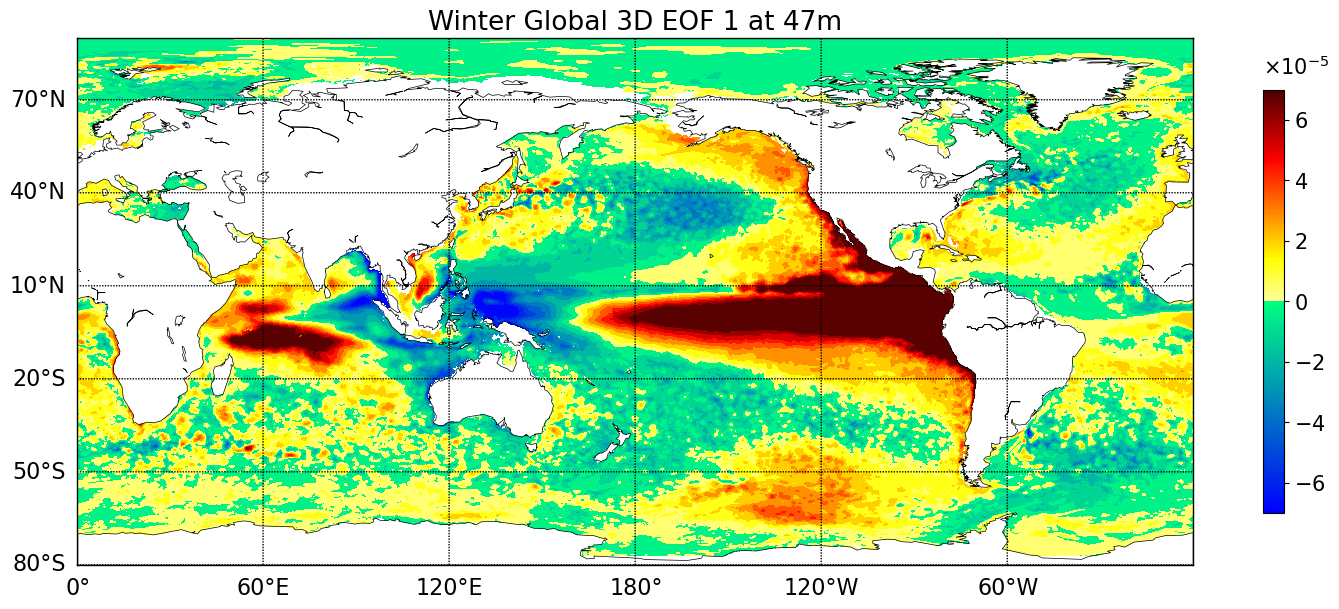

In [8]:
depth_ind = 17

depth = depths[depth_ind]

if mode == 1:
    dat = -EOF[depth_ind,:,:]
else:
    dat = EOF[depth_ind,:,:]
clip = np.nanmax(abs(dat)) # set min and max values
clip = .00007 # set min and max values
#clip = 0.0001
dat = np.maximum(np.minimum(dat, clip), -clip) # climp min and max values

#Plot first depth
fig, ax = plt.subplots(figsize=(18., 11.)) 
#plt.figure(figsize=(15., 6.))

mymap = Basemap(projection='cyl',llcrnrlat=cut_lat[0],urcrnrlat=cut_lat[-1],llcrnrlon=cut_lon[0],urcrnrlon=cut_lon[-1],resolution='c')
mymap.drawcoastlines(color='black', linewidth=.5)
mymap.drawmapboundary()
mymap.drawparallels(np.arange(cut_lat[0],cut_lat[-1],30), labels = [1,0,0,0], fontsize = label_sz)
mymap.drawmeridians(np.arange(cut_lon[0],cut_lon[-1],60), labels = [0,0,0,1], fontsize = label_sz)

norm = mpl.colors.Normalize(vmin=-clip, vmax=clip)
ax.contourf(cut_lon, cut_lat,  dat, 20, cmap = newcmp2, norm= norm)

if depth_ind == 0:
    plt.title(f"{month} {region} 3D EOF {mode} at Surface", size = title_sz)
else:    
    plt.title(f"{month} {region} 3D EOF {mode} at {round(depth)}m", size = title_sz)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=newcmp2)
sm.set_array([]) 
#cbar = plt.colorbar(sm, ax = ax, format = mpl.ticker.ScalarFormatter(useMathText=True), shrink = .97)
cbar = plt.colorbar(sm, ax = ax, format = mpl.ticker.ScalarFormatter(useMathText=True), shrink = .5)
cbar.ax.yaxis.get_offset_text().set_fontsize(15) # change exp size
cbar.ax.yaxis.OFFSETTEXTPAD = 11           # moving exponent so it doesnt overlap with top of colorbar
cbar.ax.yaxis.set_offset_position('left')  # setexponent so it is more left 
cbar.ax.tick_params(labelsize=15)    # set label size of ticks
cbar.formatter.set_powerlimits((0, 0))     # formatting scientific notation
cbar.update_ticks()


saveName = "D:/SCIL/Paper Figs/" + region + "/DJF_" + region + "_depth" + str(depth_ind) + "_mode_" + str(mode) + "_3D"

plt.savefig(saveName)

## Section 4.2
### DO NOT RUN ME

In [154]:
import imageio
def make_EOF_GIF(mode, EOF, cut_lat, cut_lon, gif_path):
    gif_frames = []
    output_dir = os.path.dirname(data_directory)
    output_dir = os.path.join(output_dir, 'EOF figs')  # Directory to save individual frames
    os.makedirs(output_dir, exist_ok=True)             # Create the directory if it doesn't exist
    title_sz = 19
    label_sz = title_sz - 3
    # Loop through depth indices to create frames
    for depth_ind in range(len(cut_depths)):
        depth = depths[depth_ind]
        dat   = -EOF[depth_ind,:,:] #624:804, 1320:1524]
    
        clip = .0002#np.nanmax(abs(dat)) # Set min and max values
        dat  = np.maximum(np.minimum(dat, clip), -clip)  # Clip min and max values
    
        fig, ax = plt.subplots(figsize=(18., 11.)) 
    
        mymap = Basemap(projection='cyl',
                        llcrnrlat=cut_lat[0],
                        urcrnrlat=cut_lat[-1],
                        llcrnrlon=cut_lon[0],
                        urcrnrlon=cut_lon[-1],
                        resolution='c')
        
        mymap.drawcoastlines(color='black', linewidth=.5)
        mymap.drawmapboundary()
        mymap.drawparallels(np.arange(cut_lat[0], cut_lat[-1], 30), labels=[1, 0, 0, 0], fontsize = label_sz)
        mymap.drawmeridians(np.arange(cut_lon[0], cut_lon[-1], 30), labels=[0, 0, 0, 1], fontsize = label_sz)
    
        norm = mpl.colors.Normalize(vmin=-clip, vmax=clip)
        cs = ax.contourf(cut_lon, cut_lat, -dat, 20, cmap=newcmp2)
    
        if depth_ind == 0:
            plt.title(f"{month} EOF {mode} at Surface", size = title_sz)
        else:    
            plt.title(f"{month} EOF {mode} at {round(depth)}m", size = title_sz)
    
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=newcmp2)
        sm.set_array([]) 
        cbar = plt.colorbar(sm, ax=ax, format=mpl.ticker.ScalarFormatter(useMathText=True), shrink=.7, pad=.05)
        cbar.ax.yaxis.get_offset_text().set_fontsize(label_sz)
        cbar.ax.yaxis.OFFSETTEXTPAD = 11
        cbar.ax.yaxis.set_offset_position('left')
        cbar.ax.tick_params(labelsize=label_sz)
        cbar.formatter.set_powerlimits((0, 0))
        cbar.update_ticks()
    
        # Save the frame
        frame_path = os.path.join(output_dir, f"frame_{depth_ind}.png")
        plt.savefig(frame_path)
        gif_frames.append(frame_path)
        plt.close(fig)
    
    # Create the GIF
    with imageio.get_writer(gif_path, mode='I', duration=500) as writer:  # duration is in seconds per frame
        for frame in gif_frames:
            image = imageio.imread(frame)
            writer.append_data(image)
    
    # Clean up temporary files
    for frame in gif_frames:
        os.remove(frame)
    
    print(f"GIF saved at {gif_path}")

In [160]:
mode = 2
fn   = 'EOF_'+str(mode)+'.nc'
fn   = os.path.join(EOF_directory, fn)       # join with EOF path
EOF_ncfile = ds(fn, 'r')
EOF = EOF_ncfile.variables['EOF']
EOF = EOF[:].filled()
EOF_ncfile.close()

area_weight = vol_weight(cut_depths, cut_lon, cut_lat)
EOF = -EOF/area_weight  # remember to div by area weight 


gif_path = os.path.join(os.path.dirname(data_directory), 'EOF figs/3D/' + month )
create_folder(gif_path)
gif_path = os.path.join(gif_path, f"eof_{mode}.gif")
make_EOF_GIF(mode, EOF, cut_lat, cut_lon, gif_path)

Folder '/Volumes/Elements/EOF figs/3D/Winter' already exists.
GIF saved at /Volumes/Elements/EOF figs/3D/Winter/eof_2.gif
